In [1]:
# %%writefile DescTools.py

import QUANTAXIS as QA
from QUANTAXIS.QAData.financial_mean import financial_dict
import pandas as pd


import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np
import sweetviz as sv

import time
import datetime

from base.JuUnits import excute_for_multidates

mpl.rcParams['font.sans-serif'] = ['SimHei','KaiTi', 'FangSong']  # 汉字字体,优先使用楷体，如果找不到楷体，则使用黑体
mpl.rcParams['font.size'] = 14  # 字体大小
mpl.rcParams['axes.unicode_minus'] = False  # 正常显示负号


from sklearn.neighbors.kde import KernelDensity  

# class Macro_Descer:
#     def __init__(self, )

def auto_describe(df):
    report = sv.analyze(finances_filted,pairwise_analysis='auto')
    report.show_notebook()
    
def fliter_codes_by_market(sse='sh',only_main=True, codes_list=None):
    '''按照市场获取股票代码，分为3类sh，sz，all，默认只获取主板
       codes_list为空时，从全市场codes中获得整个子市场的codes
    '''
    condition = []
    if sse =='all':
        condition.append('6')
        condition.append('0')
        if not only_main:
            condition.append('3')
            
    if sse == 'sh':
        condition.append('6')
    if sse == 'sz':
        condition.append('0')
        if not only_main:
            condition.append('3')
            
    assert len(condition), '参数错误，检查sse内容'
    if codes_list is None:
        stocks = QA.QA_fetch_stock_list()
        return stocks[stocks.code.map(lambda x:x[0] in condition)].code.unique().tolist()
    else:
        return [code for code in codes_list if code[0] in condition]

def get_Q1_list(start, end):
    return [str(y)+'-03-31' for y in range(int(start), int(end)+1)]

def get_Q2_list(start, end):
    return [str(y)+'-06-30' for y in range(int(start), int(end)+1)]

def get_Q3_list(start, end):
    return [str(y)+'-09-30' for y in range(int(start), int(end)+1)]

def get_Q4_list(start, end):
    return [str(y)+'-12-31' for y in range(int(start), int(end)+1)]


def drop_by_quantile_multidates(obj, floor=.00,upper=1., column=None):
    return excute_for_multidates(obj, drop_by_quantile, floor=floor,upper=upper, column=column).sort_index()

def drop_by_quantile(obj, floor=.00,upper=1., column=None):
    if isinstance(obj, pd.Series):
        qt = obj.quantile([floor,upper])
        return obj[(obj>=qt[floor]) & (obj<=qt[upper])]
    
    if isinstance(obj, pd.DataFrame):
        assert column, 'COLUMN CANT be NONE when obj is dataframe'
        qt = obj[column].quantile([floor,upper])
        return obj[(obj[column]>=qt[floor]) & (obj[column]<=qt[upper])]
        
    raise TypeError('obj must be series or dataframe')

def get_blockname_from_stock(code, hy_type='gn'):
    code_ = code
    if isinstance(code, str):
        code_ = [code]
    try:
        res = QA.QA_fetch_stock_block_adv(code=code_)
    except Exception as e:
        print(e,'get_stock_blockname ：code error')
        return None
    res = res.data
    return res[res['type']==hy_type].index.get_level_values('blockname').values

def get_codes_from_blockname(blockname, sse='all', only_main=True):
    codes = QA.QA_fetch_stock_block_adv(blockname=blockname).code
    if sse != 'all' and len(codes)!=0:
        codes = fliter_codes_by_market(sse=sse, only_main=only_main, codes_list=codes)
    return codes

def get_stock_name(code):
    if isinstance(code, list):
        return QA.QA_fetch_stock_name(code).name
    if isinstance(code, str):
        return QA.QA_fetch_stock_name(code)
    raise TypeError('code MUST BE list or str')
    
def get_all_blocks(type_):
    a = QA.QA_fetch_stock_block_adv().data
    return a[a['type']=='type_'].index.get_level_values('blockname').unique().to_list()

def get_rank(data, codes=None,quantile=False, column=None):
    '''get_rank(a,['000001','000002'],column=['totalAssets','ROE'])'''
    if len(data.index.names) >= 2:
        res = excute_for_multidates(data, lambda x: x.rank(ascending=False,pct=quantile))
        if codes:
            if column:
                res=res.loc[pd.IndexSlice[:,codes], column]
            else:
                res=res.loc[pd.IndexSlice[:,codes],slice(None)]
    else:
        res =  data.rank(ascending=False,pct=quantile)
        if codes:
            res = res.loc[codes]
    return res

In [2]:
# QA.QA_fetch_stock_block_adv().get_code('600419').data
# code_all = QA.QA_fetch_stock_list().code.unique().tolist()
code_all = fliter_codes_by_market('all')
code_all

['000001',
 '000002',
 '000004',
 '000005',
 '000006',
 '000007',
 '000008',
 '000009',
 '000010',
 '000011',
 '000012',
 '000014',
 '000016',
 '000017',
 '000019',
 '000020',
 '000021',
 '000023',
 '000025',
 '000026',
 '000027',
 '000028',
 '000029',
 '000030',
 '000031',
 '000032',
 '000034',
 '000035',
 '000036',
 '000037',
 '000038',
 '000039',
 '000040',
 '000042',
 '000045',
 '000046',
 '000048',
 '000049',
 '000050',
 '000055',
 '000056',
 '000058',
 '000059',
 '000060',
 '000061',
 '000062',
 '000063',
 '000065',
 '000066',
 '000068',
 '000069',
 '000070',
 '000078',
 '000088',
 '000089',
 '000090',
 '000096',
 '000099',
 '000100',
 '000150',
 '000151',
 '000153',
 '000155',
 '000156',
 '000157',
 '000158',
 '000159',
 '000166',
 '000301',
 '000333',
 '000338',
 '000400',
 '000401',
 '000402',
 '000403',
 '000404',
 '000407',
 '000408',
 '000409',
 '000410',
 '000411',
 '000413',
 '000415',
 '000416',
 '000417',
 '000419',
 '000420',
 '000421',
 '000422',
 '000423',
 '000425',

In [3]:
%%time
# codes = QA.QA_fetch_stock_block_adv().get_block(['婴童概念','乳业']).code
# QA.QA_fetch_stock_block_adv().data

# QA.QA_fetch_stock_block_adv(blockname='养老金').code

# res = QA.QA_fetch_stock_block_adv(code = ['000001']).data
# res[res['type']=='gn'].index.get_level_values('blockname').values

# QA.QA_fetch_stock_block_adv().block_name
a = QA.QA_fetch_stock_block_adv().data
a[a['type']=='swhy'].index.get_level_values('blockname').unique().to_list()

    
# a = QA.QA_fetch_stock_list().code.unique().tolist()
# fliter_codes_by_market(sse='sz',codes_list=QA.QA_fetch_stock_block_adv(blockname='养老金').code)
# get_codes_from_blockname('白酒',sse='sh', only_main=True)


# b = QA.QA_fetch_stock_block_adv(blockname='白酒').data
# d = b[b['type']=='tdxhy'].index.get_level_values('code')
# print(get_stock_name(fliter_codes_by_market(sse='sh', codes_list=d.to_list())))
# fliter_codes_by_market(sse='sh', codes_list=d)

Wall time: 655 ms


In [59]:
%%time
# QA.QA_fetch_financial_report_adv('000001',get_Q4_list(2012,2019)).data
# QA.QA_fetch_financial_report_adv('000001','2017','2017',ltype='CN').data
finances = QA.QA_fetch_financial_report_adv(code_all,get_Q1_list('2017','2017'))#.data


# finances.describe(include = 'all')
# finances['totalAssets'] = finances['totalAssets'].apply(lambda x: round(x/100000000,2))
# finances['ROE'] = finances['ROE'].apply(lambda x: round(x,1))
# finances.describe()
# finances.quantile([.01,.05,.1,.9,.95,.99])
# finances


        
# print(finances['ROE'].rank())
finances = finances.get_key(code_all, ['2017-03-31'], ['totalAssets','ROE'])

# a = finances.sort_index(level='report_date').loc[(slice(pd.Timestamp('2017-03-31'),pd.Timestamp('2017-06-30')), ['000001','000002','000004']),['totalAssets','ROE']]
# # b = a.groupby(level=0, group_keys=False).apply(lambda x: x.rank(ascending=False,pct=False))
# # # a = finances.data.sort_index(level='report_date').loc[(slice(pd.Timestamp('2017-03-31'),pd.Timestamp('2017-06-30')), ['000001','000002','000004']),['totalAssets','ROE']]['ROE']
# # # b = a.groupby(level=0, group_keys=False).apply(lambda x: x.rank(ascending=False,pct=False))
# print(get_rank(a,['000001','000001'],column=['totalAssets','ROE']))
# print(a)

print(finances)

                     totalAssets    ROE
report_date code                       
2017-03-31  000001  3.006195e+12  2.992
            000002  8.867535e+11  0.610
            000004  2.238019e+08 -0.985
            000005  2.611314e+09 -0.797
            000006  1.326550e+10  2.033
...                          ...    ...
            603993  8.808833e+10  3.089
            603996  3.040247e+09  0.411
            603997  1.951535e+09  4.588
            603998  1.294023e+09  1.883
            603999  1.948274e+09  0.861

[2635 rows x 2 columns]
Wall time: 1.37 s


In [62]:
# finances_filted = finances[(finances['totalAssets'] > 2.9201) & (finances['totalAssets'] < 6243.5915)& (finances['ROE'] > -1.795)& (finances['ROE'] < 5.700)]
finances_filted = drop_by_quantile_multidates(finances,.1,0.90,'ROE')

# finances_filted.index.names
# finances['ROE'].loc[pd.IndexSlice['2017-03-31'],:].index
# finances.data.loc[pd.IndexSlice['2017-03-31',],:]
finances_filted
# excute_for_multidate(obj, drop_by_quantile, floor=floor,upper=upper, column=column)

totalAssets    ROE
report_date code                       
2017-03-31  000001  3.006195e+12  2.992
            000002  8.867535e+11  0.610
            000006  1.326550e+10  2.033
            000007  4.852911e+08  0.075
            000008  7.982302e+09  0.152
...                          ...    ...
            603991  5.739537e+08  1.318
            603993  8.808833e+10  3.089
            603996  3.040247e+09  0.411
            603998  1.294023e+09  1.883
            603999  1.948274e+09  0.861

[2108 rows x 2 columns]


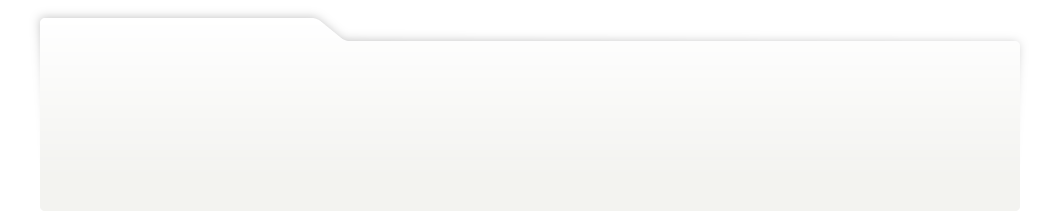
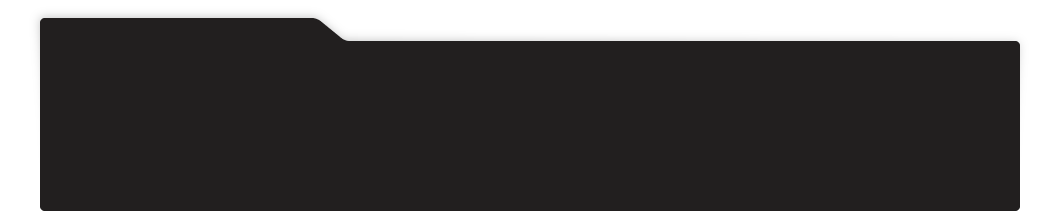
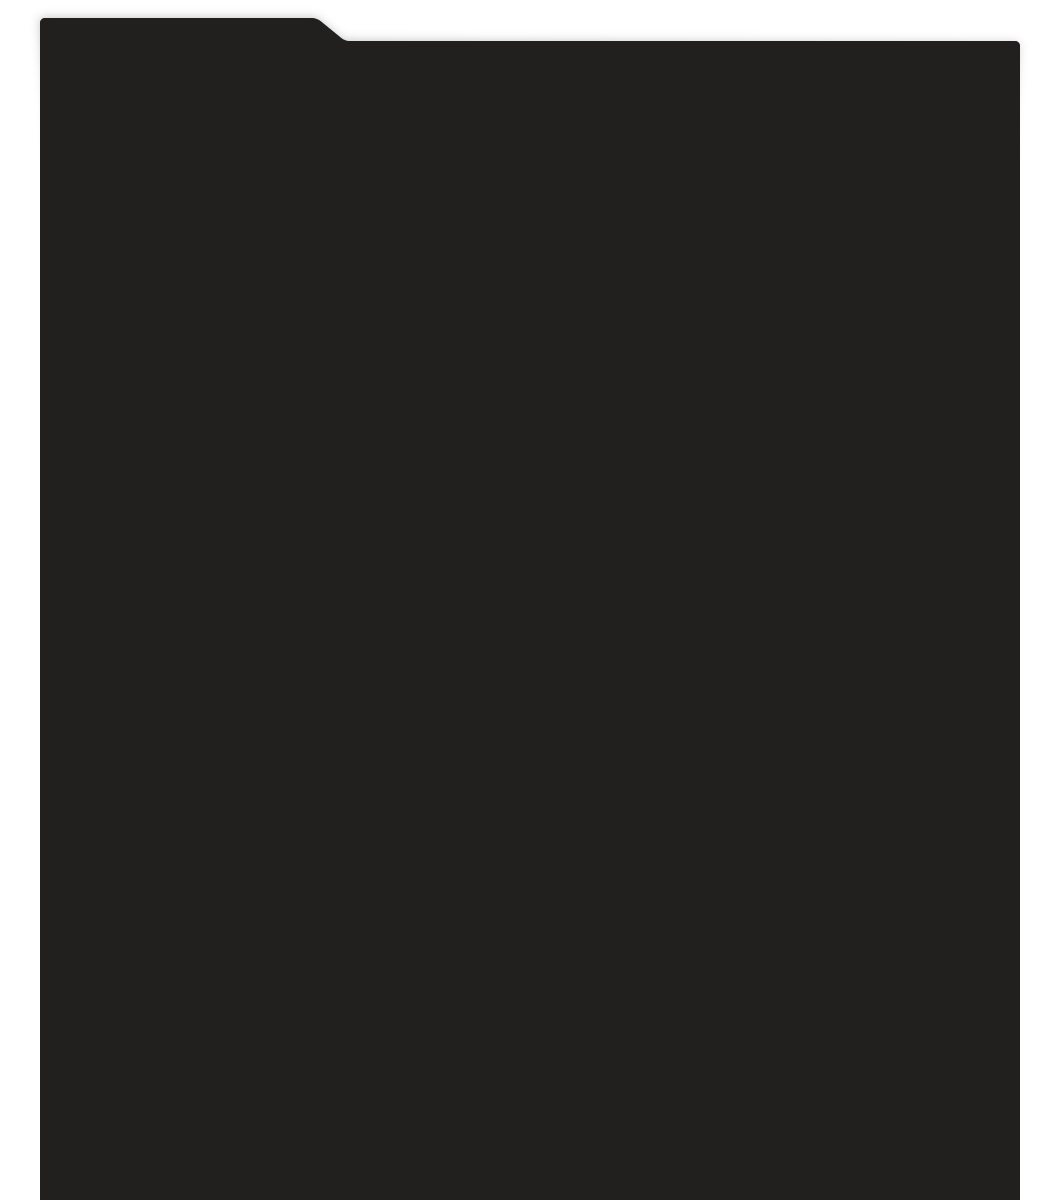
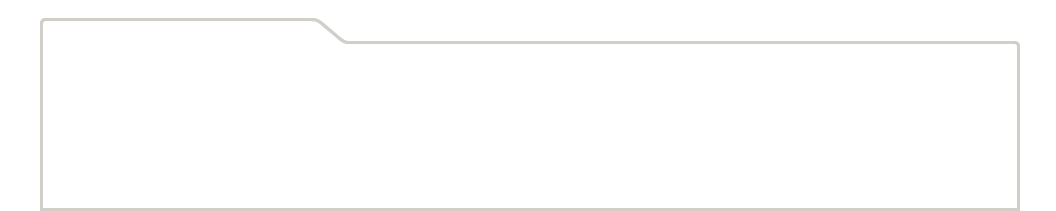
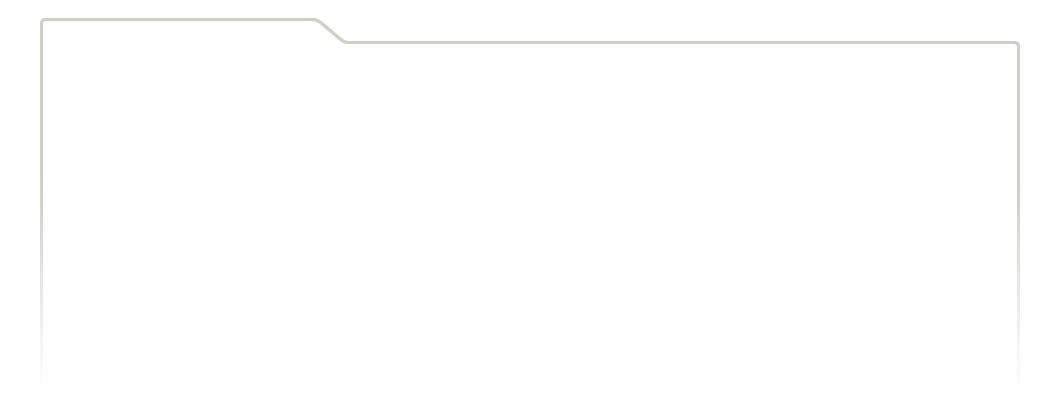
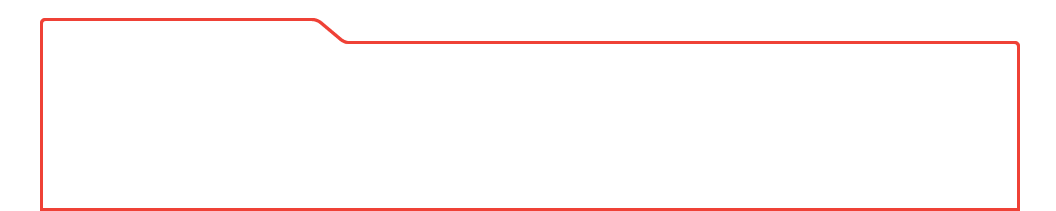
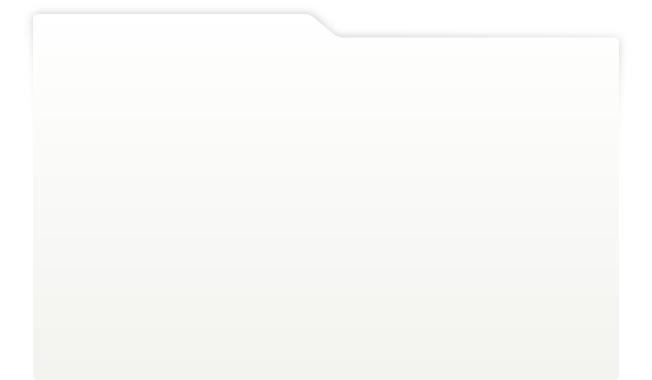
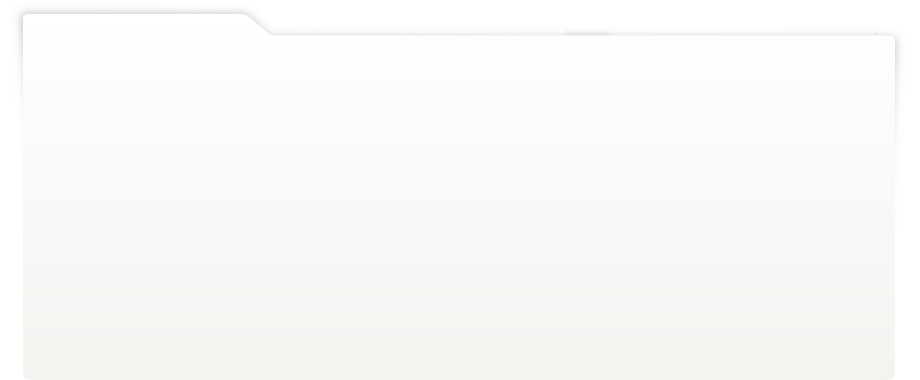
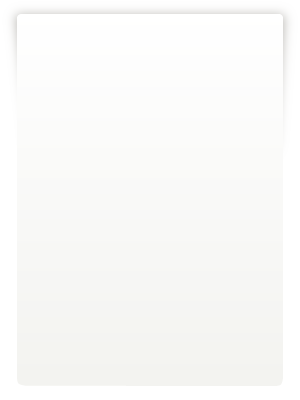
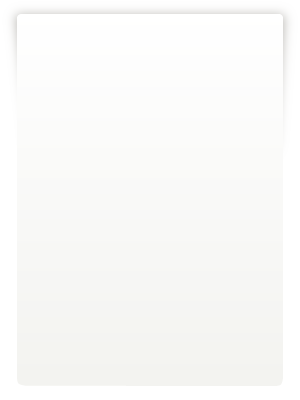
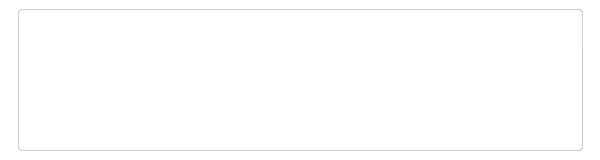
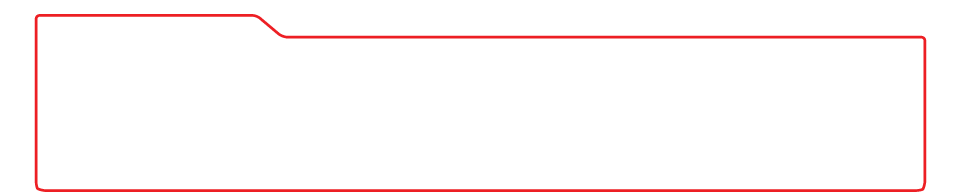
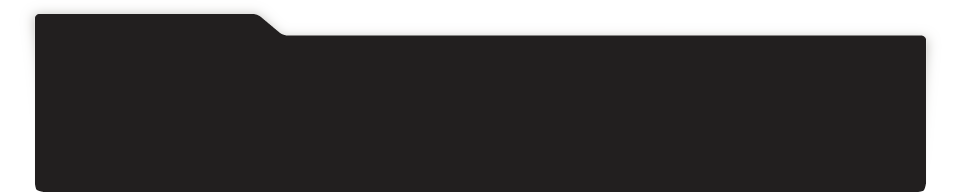
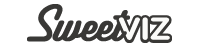
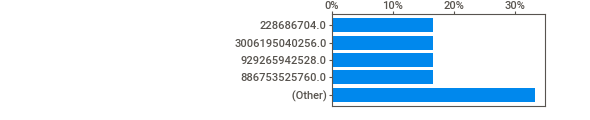
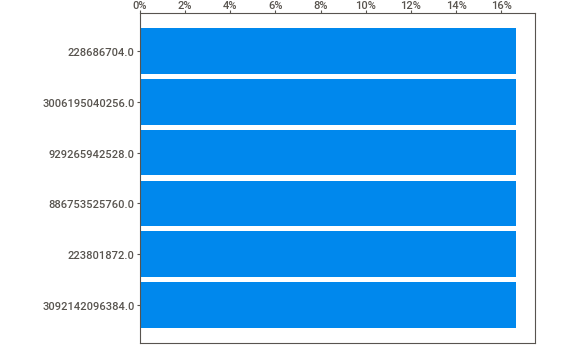
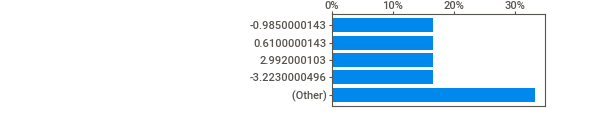
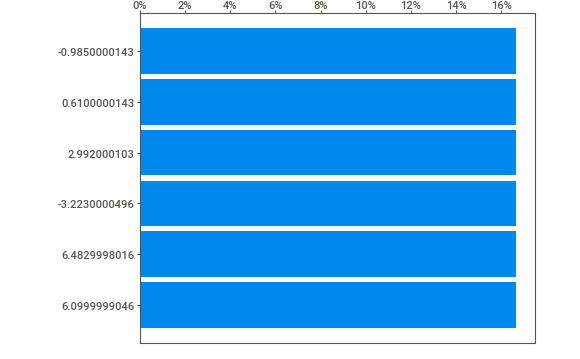
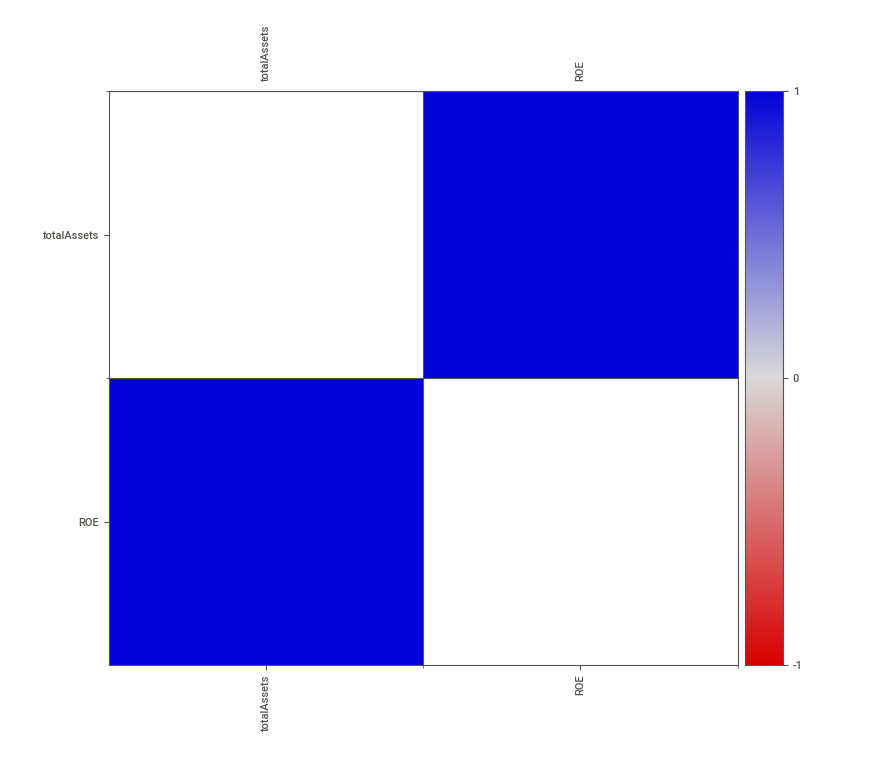
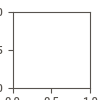

In [6]:
# get_Q4_list(2012,2019)
# import sweetviz as sv
report = sv.analyze(finances_filted,pairwise_analysis='auto')
report.show_notebook()

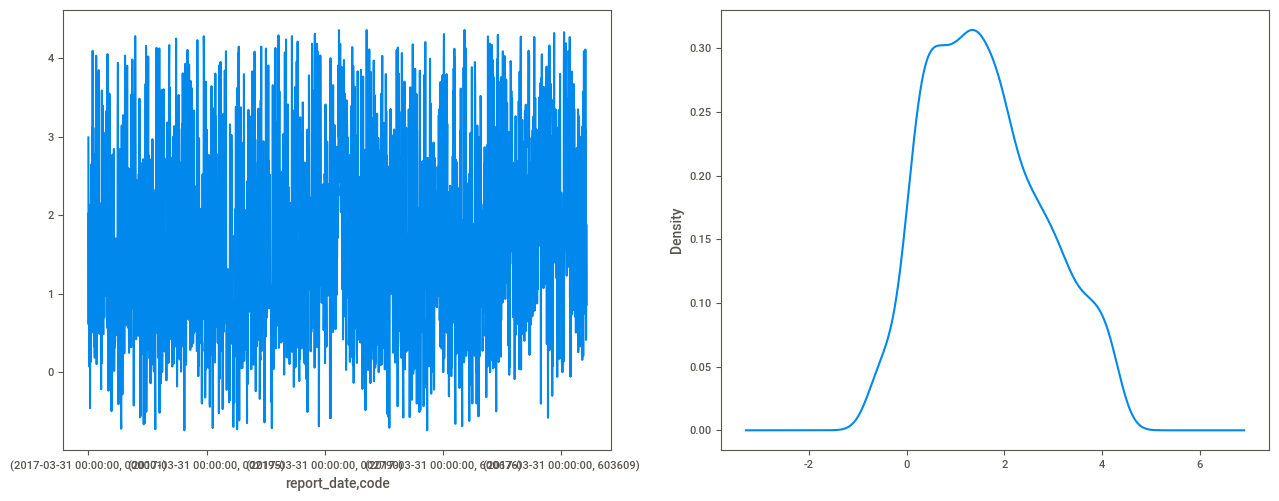

In [66]:
fig = plt.figure(figsize=(1120/72,420/72))
finances_filted['ROE'].plot(ax=fig.add_subplot(1,2,1))
# plt.scatter(finances_filted['ROE'].index.get_level_values('code'),finances_filted['ROE'].values)
finances_filted['ROE'].plot(kind="kde",ax=fig.add_subplot(1,2,2))
# finances_filted['ROE'].describe()
# finances_filted['totalAssets'].mean()
# plt.show()


{'algorithm': 'auto', 'atol': 0, 'bandwidth': 0.5, 'breadth_first': True, 'kernel': 'epanechnikov', 'leaf_size': 40, 'metric': 'euclidean', 'metric_params': None, 'rtol': 0}


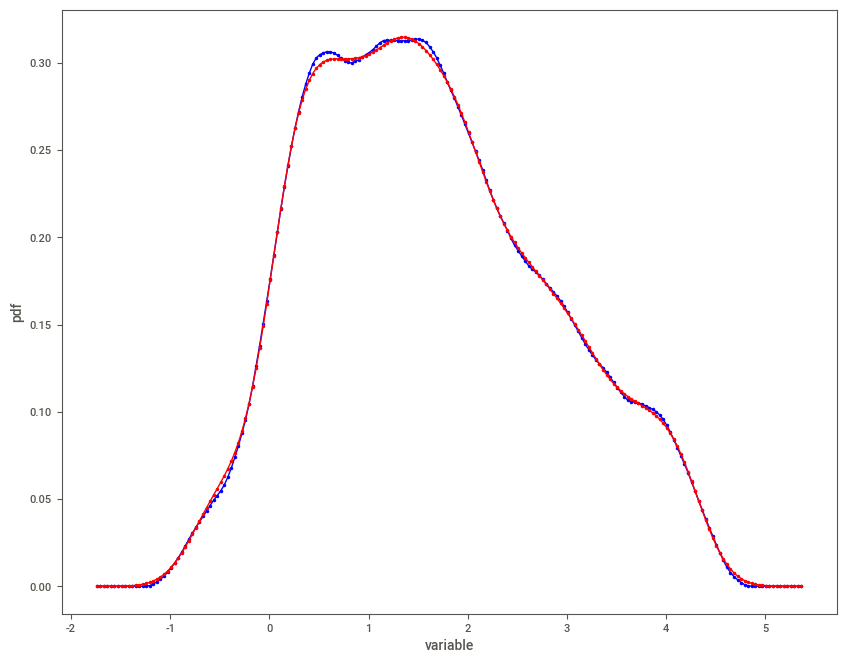

In [99]:
X_plot = np.linspace((finances_filted['ROE']).min()-1, (finances_filted['ROE']).max()+1, 200)[:, np.newaxis]
kde = KernelDensity(kernel='epanechnikov', bandwidth=0.5).fit((finances_filted['ROE']).values.reshape(-1, 1))  
log_dens = kde.score_samples(X_plot)  # 返回的是点x对应概率密度的log值，需要使用exp求指数还原
print(kde.get_params())
plt.figure(figsize = (10, 8))  # 设置画布大小
plt.plot(X_plot, np.exp(log_dens), marker='.', linewidth=1, c="b", label='kernel density')
plt.xlabel('variable')
plt.ylabel('pdf')

kde = KernelDensity(kernel='gaussian', bandwidth=0.25).fit((finances_filted['ROE']).values.reshape(-1, 1))  
log_dens = kde.score_samples(X_plot)
# # kde = KernelDensity(kernel='epanechnikov', bandwidth=1).fit(((finances_filted['ROE']-finances_filted['ROE'].mean())/finances_filted['ROE'].std()).values.reshape(-1, 1))  # 高斯核密度估计
plt.plot(X_plot, np.exp(log_dens), marker='.', linewidth=1, c="r", label='kernel density')


plt.show()

# finances_filted.columns.size

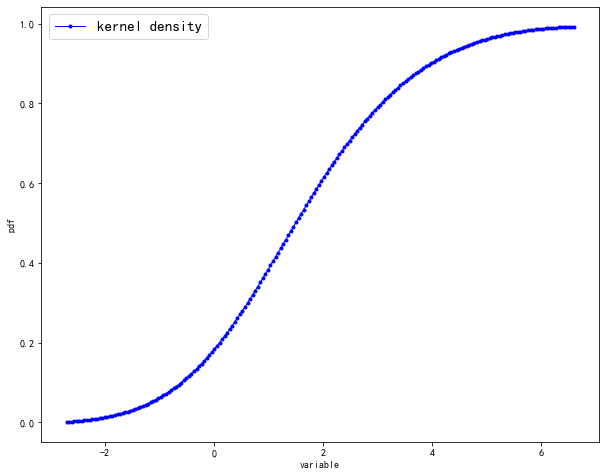

In [49]:
plt.figure(figsize = (10, 8))  # 设置画布大小
plt.plot(X_plot, np.cumsum(np.exp(log_dens)*np.abs(X_plot[0]-X_plot[1])), marker='.', linewidth=1, c="b", label='kernel density')
plt.xlabel('variable')
plt.ylabel('cdf') 
plt.legend(fontsize = 15)  # 显示图例,设置图例字体大小
plt.show()


In [59]:
np.exp( kde.score_samples(np.array([1.3,1.3]).reshape(-1,1)))

array([0.28077963, 0.28077963])

In [62]:
np.exp(kde.score(np.array([1.3,1.3]).reshape(-1,1)))

0.07883720328173173

In [356]:
c = pd.DataFrame([{"a":11,"b":123,"c":1255},{"a":11,"b":2123,"c":222},{"a":333,"b":3333,"c":3}])
print(c.set_index('a'))
print(c.rank())
print(c.set_index('a').rank())


        b     c
a              
11    123  1255
11   2123   222
333  3333     3
     a    b    c
0  1.5  1.0  3.0
1  1.5  2.0  2.0
2  3.0  3.0  1.0
       b    c
a            
11   1.0  3.0
11   2.0  2.0
333  3.0  1.0


In [13]:
ll = [1,2,3,4,5]
head, body, *tail = ll
print(head, body, tail)

1 2 [3, 4, 5]
